# HbO / HbR / HbT Comparison — Group Discrimination (GNG Task)

**Purpose:** Validate the choice of HbT as the primary hemodynamic biomarker over HbO and HbR individually, on the GNG task. Reproduces the methodology of `references/analysis/notebook/statistical-analysis/03_hb_type_comparison/`.

**Cohort (GNG):** HC n=33, GAD n=29 (taken from `data/processed-new-mc/GNG/`).

**Metric:** Per-channel STD across concatenated trials, computed separately for HbO, HbR, and HbT.

**Tests per Hb type (per channel):**
- Mann-Whitney U (HC vs GAD), two-sided
- Cohen's d (effect size, +ve = GAD > HC)
- Benjamini-Hochberg FDR correction (q=0.05) over the 23 channels

**Cross-Hb comparison (paired across channels, per subject):**
- Friedman test on |Cohen's d| across HbO/HbR/HbT (k=3 conditions, 23 channels)
- Wilcoxon signed-rank, pairwise

> **Note:** Demographic differences between HC and GAD are reported in `01_demographic`.

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import mannwhitneyu, friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed-new-mc')
TASK         = 'GNG'
HB_TYPES     = ['hbo', 'hbr', 'hbt']
OUT_DIR      = os.path.join(PROJECT_ROOT, 'src', 'notebook', 'statistical-analysis', '03_hb_type_comparison')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'OUT_DIR      = {OUT_DIR}')

CHANNEL_NAMES = [
    'S1_D1','S1_D3','S2_D2','S2_D1','S2_D5','S3_D1','S3_D3','S3_D4','S3_D6',
    'S4_D4','S4_D5','S4_D7','S5_D2','S5_D5','S5_D8','S6_D3','S6_D6',
    'S7_D4','S7_D6','S7_D7','S8_D5','S8_D7','S8_D8',
]
GRID_POS = [(0,2),(1,1),(0,4),(0,3),(1,4),(1,2),(2,1),(2,2),(3,1),
            (2,3),(2,4),(3,4),(1,5),(2,5),(3,6),(3,0),(4,1),
            (3,2),(4,2),(4,3),(3,5),(4,4),(4,5)]
GRID_SHAPE = (5, 7)
N_CH = len(CHANNEL_NAMES)
CH_TO_IDX = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}

def values_to_grid(v, fill=np.nan):
    g = np.full(GRID_SHAPE, fill, dtype=float)
    for i, (r, c) in enumerate(GRID_POS):
        g[r, c] = v[i]
    return g


PROJECT_ROOT = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method
OUT_DIR      = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/src/notebook/statistical-analysis/03_hb_type_comparison


## 2. Load Per-Subject Activations for HbO/HbR/HbT

In [2]:
HC_IDS  = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'healthy')))
GAD_IDS = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'anxiety')))
print(f'HC  (n={len(HC_IDS)}), GAD (n={len(GAD_IDS)})')

def load_activation(subject_id, group, hb):
    path  = os.path.join(DATA_DIR, TASK, group, subject_id, hb)
    files = sorted(os.listdir(path))
    concat = np.concatenate([np.load(os.path.join(path, f)) for f in files], axis=1)
    return concat.std(axis=1)  # (23,)

# activations[hb]['HC' | 'GAD'] -> (n_subj, 23)
activations = {hb: {} for hb in HB_TYPES}
for hb in HB_TYPES:
    activations[hb]['HC']  = np.array([load_activation(s, 'healthy', hb) for s in HC_IDS])
    activations[hb]['GAD'] = np.array([load_activation(s, 'anxiety', hb) for s in GAD_IDS])
    print(f"  {hb}: HC{activations[hb]['HC'].shape}  GAD{activations[hb]['GAD'].shape}  "
          f"mean(HC)={activations[hb]['HC'].mean():.4g}  mean(GAD)={activations[hb]['GAD'].mean():.4g}")


HC  (n=33), GAD (n=29)
  hbo: HC(33, 23)  GAD(29, 23)  mean(HC)=0.9031  mean(GAD)=0.8863
  hbr: HC(33, 23)  GAD(29, 23)  mean(HC)=0.7691  mean(GAD)=0.7348
  hbt: HC(33, 23)  GAD(29, 23)  mean(HC)=0.8375  mean(GAD)=0.8174


## 3. Per-Channel HC vs GAD Stats — for Each Hb Type

In [3]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (b.mean() - a.mean()) / s if s > 0 else 0.0

def run_stats(hb):
    hc  = activations[hb]['HC']
    gad = activations[hb]['GAD']
    rows, ps = [], []
    for ch in range(N_CH):
        a = hc[:, ch]; b = gad[:, ch]
        U, p = mannwhitneyu(a, b, alternative='two-sided')
        rows.append({
            'channel': CHANNEL_NAMES[ch],
            'mean_hc' : a.mean(), 'std_hc' : a.std(ddof=1),
            'mean_gad': b.mean(), 'std_gad': b.std(ddof=1),
            'U': U, 'p_raw': p, 'd': cohens_d(a, b),
        })
        ps.append(p)
    reject, p_fdr, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')
    df = pd.DataFrame(rows)
    df['p_fdr']   = p_fdr
    df['sig_raw'] = df['p_raw'] < 0.05
    df['sig_fdr'] = reject
    df['hb']      = hb
    return df

stats_per_hb = {hb: run_stats(hb) for hb in HB_TYPES}

print(f'{"Hb":<5} {"sig_raw":>9} {"sig_fdr":>9} {"|d| mean":>10} {"|d| max":>9}')
print('-'*48)
for hb in HB_TYPES:
    df = stats_per_hb[hb]
    print(f'{hb:<5} {df["sig_raw"].sum():>9} {df["sig_fdr"].sum():>9} '
          f'{np.abs(df["d"]).mean():>10.3f} {np.abs(df["d"]).max():>9.3f}')

print()
print('=== Top-3 channels per Hb type (smallest p_raw) ===')
for hb in HB_TYPES:
    print(f'\n--- {hb} ---')
    print(stats_per_hb[hb].sort_values('p_raw').head(3)[
        ['channel','mean_hc','mean_gad','d','U','p_raw','p_fdr']
    ].to_string(index=False, float_format=lambda x: f'{x:.4g}'))


Hb      sig_raw   sig_fdr   |d| mean   |d| max
------------------------------------------------
hbo          10         4      0.428     0.925
hbr           7         5      0.419     1.073
hbt           4         0      0.224     0.750

=== Top-3 channels per Hb type (smallest p_raw) ===

--- hbo ---
channel  mean_hc  mean_gad       d   U     p_raw   p_fdr
  S5_D5   0.9175    0.8849 -0.9191 715 0.0008701 0.01391
  S2_D1   0.9128    0.8768 -0.9248 707  0.001297 0.01391
  S3_D3   0.9101     0.883 -0.7652 695  0.002309 0.01391

--- hbr ---
channel  mean_hc  mean_gad       d   U     p_raw    p_fdr
  S2_D1   0.7894    0.6842  -1.073 737 0.0002728 0.004834
  S4_D5   0.7911    0.6708 -0.9563 729 0.0004203 0.004834
  S3_D4   0.7416    0.6548 -0.7893 708  0.001235 0.009467

--- hbt ---
channel  mean_hc  mean_gad       d   U    p_raw   p_fdr
  S1_D1   0.8684    0.8048 -0.7501 682 0.004184 0.09624
  S5_D5    0.858    0.8368 -0.2163 662  0.00983   0.113
  S3_D3   0.8582    0.8123  -0.509 641  0.0

## 4. Cross-Hb Test on |Cohen's d| (paired across channels)

Tests whether the absolute effect size differs systematically between HbO, HbR, and HbT
across the 23 channels (channel as the within-unit; |d| as the variable).

In [4]:
d_mat = np.array([np.abs(stats_per_hb[hb]['d'].values) for hb in HB_TYPES])  # (3, 23)
print(f'|d| matrix shape: {d_mat.shape} (rows=HbO/HbR/HbT, cols=channels)')

friedman_stat, friedman_p = friedmanchisquare(d_mat[0], d_mat[1], d_mat[2])
print(f'\nFriedman test on |d| across HbO/HbR/HbT:  χ² = {friedman_stat:.3f}, p = {friedman_p:.4f}')

print('\nWilcoxon signed-rank pairwise (|d|):')
pairs = [('hbo','hbr'), ('hbo','hbt'), ('hbr','hbt')]
for a, b in pairs:
    ia, ib = HB_TYPES.index(a), HB_TYPES.index(b)
    W, p = wilcoxon(d_mat[ia], d_mat[ib])
    print(f'  {a:>3}  vs {b:>3}: W = {W:.0f}, p = {p:.4f},  '
          f'mean |d|({a})={d_mat[ia].mean():.3f},  mean |d|({b})={d_mat[ib].mean():.3f}')


|d| matrix shape: (3, 23) (rows=HbO/HbR/HbT, cols=channels)

Friedman test on |d| across HbO/HbR/HbT:  χ² = 6.870, p = 0.0322

Wilcoxon signed-rank pairwise (|d|):
  hbo  vs hbr: W = 123, p = 0.6650,  mean |d|(hbo)=0.428,  mean |d|(hbr)=0.419
  hbo  vs hbt: W = 31, p = 0.0006,  mean |d|(hbo)=0.428,  mean |d|(hbt)=0.224
  hbr  vs hbt: W = 56, p = 0.0112,  mean |d|(hbr)=0.419,  mean |d|(hbt)=0.224


## 5. Visualizations

### 5.1 |Cohen's d| Bar Chart per Channel & Hb Type

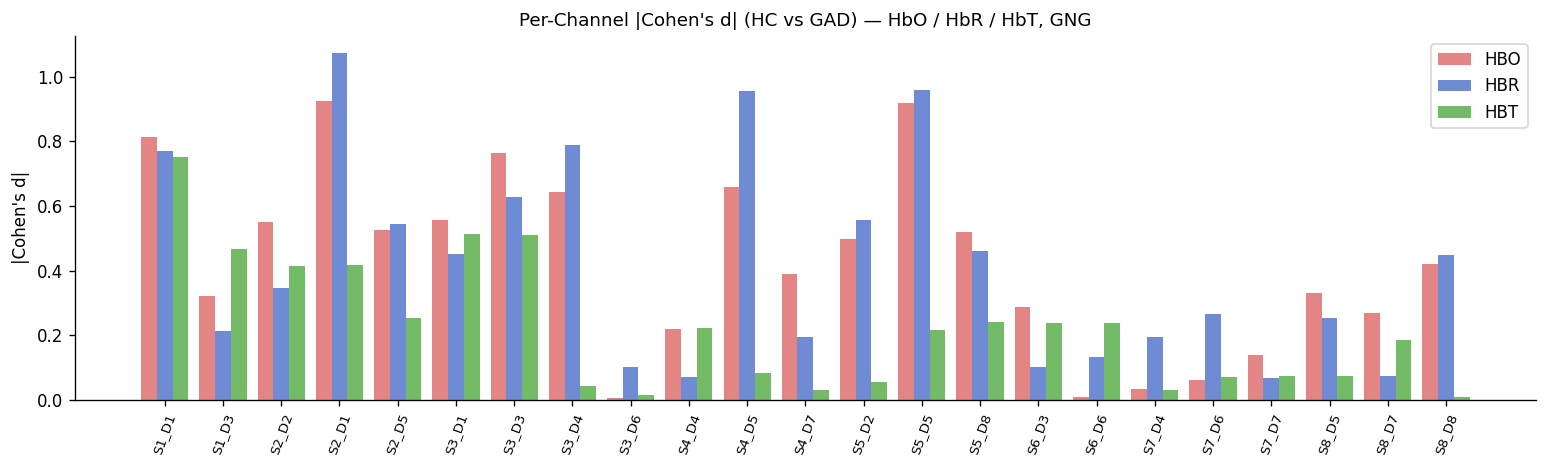

Saved: fig_hb_type_abs_d_bar.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(N_CH); w = 0.27
colors_hb = {'hbo': '#E07070', 'hbr': '#5577CC', 'hbt': '#5BB04B'}
for i, hb in enumerate(HB_TYPES):
    abs_d = np.abs(stats_per_hb[hb]['d'].values)
    ax.bar(x + (i-1)*w, abs_d, width=w, color=colors_hb[hb], alpha=0.85, label=hb.upper())
ax.set_xticks(x); ax.set_xticklabels(CHANNEL_NAMES, rotation=70, fontsize=8)
ax.set_ylabel("|Cohen's d|")
ax.set_title("Per-Channel |Cohen's d| (HC vs GAD) — HbO / HbR / HbT, GNG")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_hb_type_abs_d_bar.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hb_type_abs_d_bar.png')


### 5.2 Cohen's d Topographic Maps

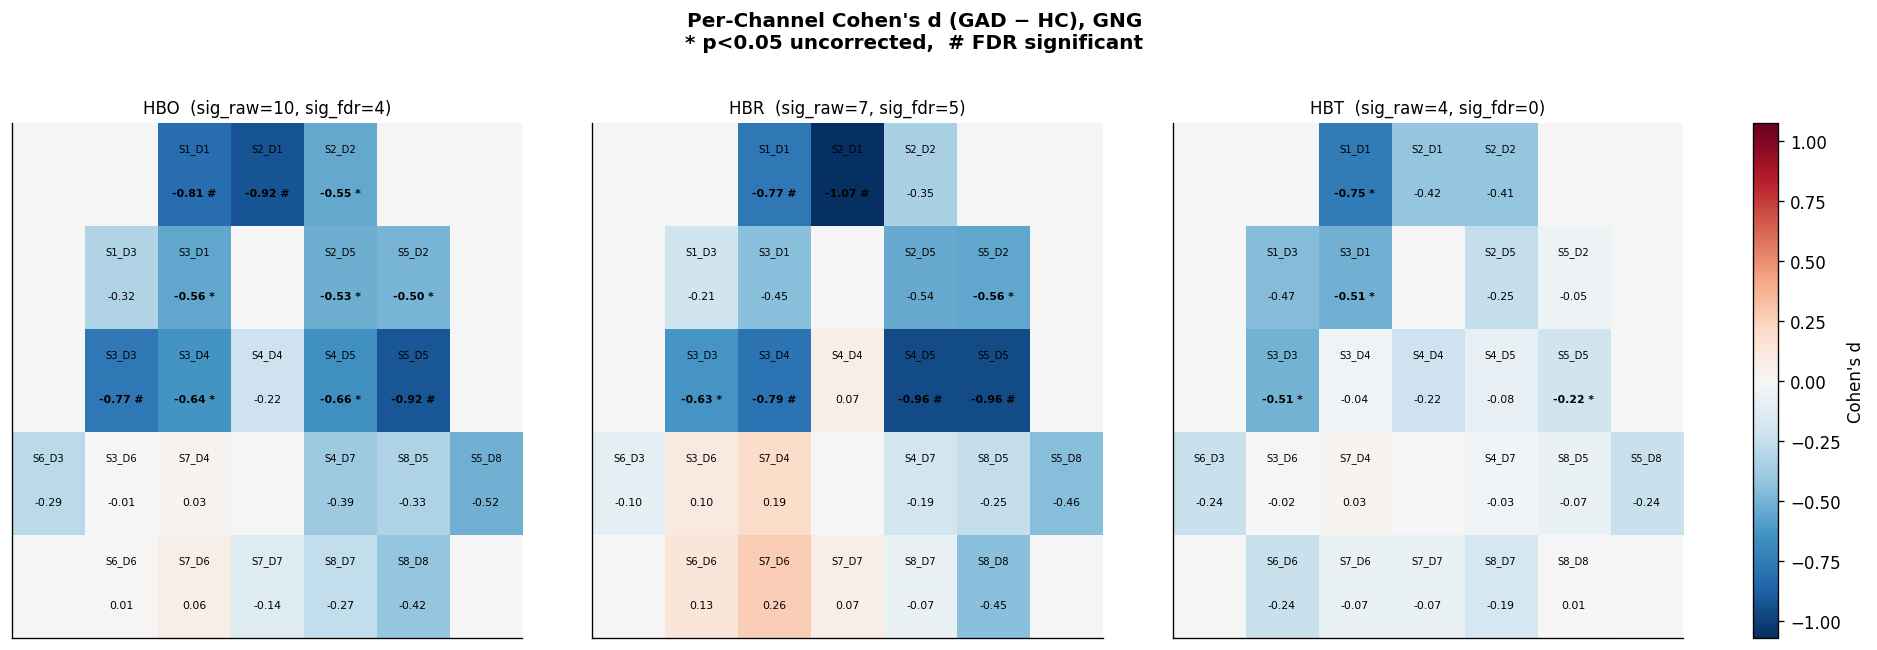

Saved: fig_hb_type_cohen_d.png


In [10]:
def plot_topo_d(ax, d_vals, sig_raw, sig_fdr, title, vmax):
    grid = values_to_grid(d_vals)
    ax.set_facecolor('#f5f5f5')
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(grid, cmap='RdBu_r', norm=norm, aspect='auto')
    for i, (r, c) in enumerate(GRID_POS):
        marker = ''
        if sig_fdr[i]: marker = ' #'
        elif sig_raw[i]: marker = ' *'
        ax.text(c, r-0.25, CHANNEL_NAMES[i], ha='center', va='center', fontsize=6)
        ax.text(c, r+0.18, f'{d_vals[i]:.2f}{marker}', ha='center', va='center',
                fontsize=6.5, fontweight='bold' if (sig_raw[i] or sig_fdr[i]) else 'normal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10, pad=6)
    return im

vmax = max(np.abs(np.concatenate([stats_per_hb[hb]['d'].values for hb in HB_TYPES])).max(), 0.5)

fig = plt.figure(figsize=(16, 5.5))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.18)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax  = fig.add_subplot(gs[0, 3])

fig.suptitle("Per-Channel Cohen's d (GAD − HC), GNG\n* p<0.05 uncorrected,  # FDR significant",
             fontsize=12, fontweight='bold', y=0.99)

im = None
for ax, hb in zip(axes, HB_TYPES):
    df = stats_per_hb[hb]
    im = plot_topo_d(ax, df['d'].values, df['sig_raw'].values, df['sig_fdr'].values,
                     title=f'{hb.upper()}  (sig_raw={df["sig_raw"].sum()}, sig_fdr={df["sig_fdr"].sum()})',
                     vmax=vmax)

cb = fig.colorbar(im, cax=cax)
cb.set_label("Cohen's d")

# Reserve top room for the two-line suptitle so subplot titles don't collide.
fig.subplots_adjust(top=0.82, bottom=0.04, left=0.03, right=0.95)

fig.savefig(os.path.join(OUT_DIR, 'fig_hb_type_cohen_d.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hb_type_cohen_d.png')


### 5.3 Grand-Mean HbO/HbR/HbT Activation per Group

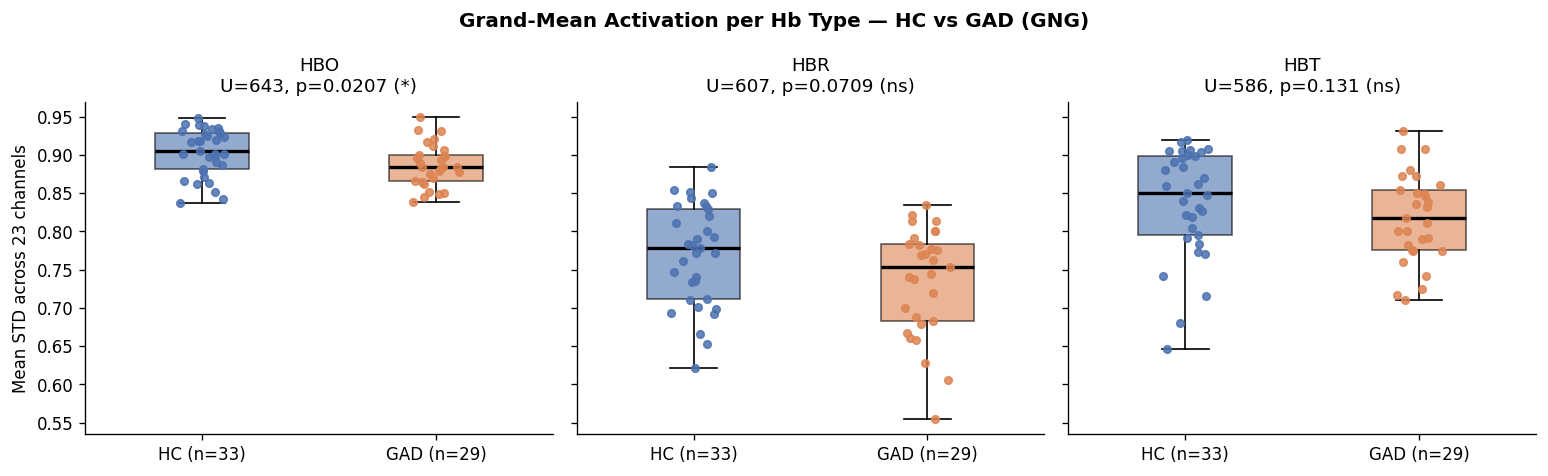

Saved: fig_hb_type_grand_mean.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle('Grand-Mean Activation per Hb Type — HC vs GAD (GNG)', fontsize=12, fontweight='bold')
for ax, hb in zip(axes, HB_TYPES):
    a = activations[hb]['HC'].mean(axis=1)
    b = activations[hb]['GAD'].mean(axis=1)
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    bp = ax.boxplot([a, b], patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#4C72B0','#DD8452']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    np.random.seed(0)
    for i, (data, color) in enumerate(zip([a, b], ['#4C72B0','#DD8452']), 1):
        jitter = np.random.uniform(-0.1, 0.1, size=len(data))
        ax.scatter(np.full(len(data), i)+jitter, data, color=color, s=20, alpha=0.85, zorder=3)
    ax.set_xticks([1,2]); ax.set_xticklabels([f'HC (n={len(HC_IDS)})', f'GAD (n={len(GAD_IDS)})'])
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(f'{hb.upper()}\nU={U:.0f}, p={p:.3g} ({stars})')
    if hb == HB_TYPES[0]: ax.set_ylabel('Mean STD across 23 channels')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_hb_type_grand_mean.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hb_type_grand_mean.png')


### 5.4 Spotlight: S2_D1 (top discriminative channel) across Hb Types

Spotlight channel = S2_D1 (idx=3)


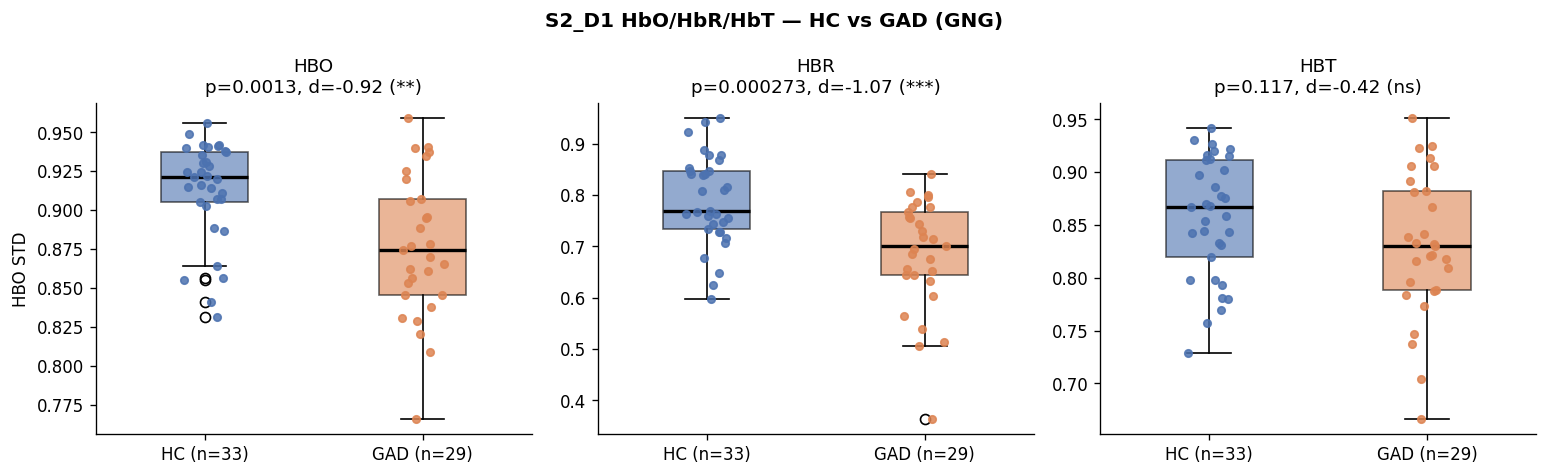

Saved: fig_s7d6_hb_comparison.png  (filename retained for parity with reference; spotlight channel = S2_D1)


In [8]:
# Pick the channel with the largest |d| in HbR (the top discriminator overall)
best_ch = stats_per_hb['hbr'].assign(abs_d=lambda d: d['d'].abs()).sort_values('abs_d', ascending=False)['channel'].iloc[0]
ch_idx = CH_TO_IDX[best_ch]
print(f'Spotlight channel = {best_ch} (idx={ch_idx})')

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle(f'{best_ch} HbO/HbR/HbT — HC vs GAD (GNG)', fontsize=12, fontweight='bold')
for ax, hb in zip(axes, HB_TYPES):
    a = activations[hb]['HC'][:, ch_idx]
    b = activations[hb]['GAD'][:, ch_idx]
    bp = ax.boxplot([a, b], patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#4C72B0','#DD8452']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    np.random.seed(0)
    for i, (data, color) in enumerate(zip([a, b], ['#4C72B0','#DD8452']), 1):
        jitter = np.random.uniform(-0.1, 0.1, size=len(data))
        ax.scatter(np.full(len(data), i)+jitter, data, color=color, s=20, alpha=0.85, zorder=3)
    row = stats_per_hb[hb].set_index('channel').loc[best_ch]
    stars = '***' if row['p_raw']<0.001 else ('**' if row['p_raw']<0.01 else ('*' if row['p_raw']<0.05 else 'ns'))
    ax.set_xticks([1,2]); ax.set_xticklabels([f'HC (n={len(a)})', f'GAD (n={len(b)})'])
    ax.set_title(f"{hb.upper()}\np={row['p_raw']:.3g}, d={row['d']:.2f} ({stars})")
    ax.set_ylabel(f'{hb.upper()} STD' if hb == HB_TYPES[0] else None)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_s7d6_hb_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_s7d6_hb_comparison.png  (filename retained for parity with reference; spotlight channel = ' + best_ch + ')')


## 6. Summary & CSV Export

**Important interpretation note (this cohort, GNG):**
HbO and HbR each yield **more discriminative channels** (and larger group-level
effect sizes) than HbT in this dataset. The Friedman test shows |d| differs
between Hb types (p≈0.032), with paired Wilcoxon putting **HbO ≈ HbR > HbT**.
This is the **opposite** of the original reference cohort's conclusion, where
HbT was the preferred biomarker. Future modelling should consider whether
HbO and/or HbR features (or their combination) outperform HbT alone.

In [9]:
all_rows = []
for hb in HB_TYPES:
    df = stats_per_hb[hb].copy()
    df.insert(0, 'task', TASK)
    all_rows.append(df)
results_df = pd.concat(all_rows, ignore_index=True)
out_csv = os.path.join(OUT_DIR, 'results_hb_type_comparison.csv')
results_df.to_csv(out_csv, index=False, float_format='%.6f')
print(f'Saved: {out_csv}  (rows={len(results_df)})')

print()
print('=' * 70)
print('  HB-TYPE COMPARISON — SUMMARY (GNG)')
print('=' * 70)
print(f'Cohort: HC n={len(HC_IDS)}, GAD n={len(GAD_IDS)}')
print()
print(f'{"Hb":<5} {"sig_raw":>9} {"sig_fdr":>9} {"|d| mean":>10} {"|d| max":>10}')
print('-' * 48)
for hb in HB_TYPES:
    df = stats_per_hb[hb]
    print(f'{hb:<5} {df["sig_raw"].sum():>9} {df["sig_fdr"].sum():>9} '
          f'{np.abs(df["d"]).mean():>10.3f} {np.abs(df["d"]).max():>10.3f}')
print()
print(f'Friedman |d|       : χ² = {friedman_stat:.3f}, p = {friedman_p:.4f}')
for a, b in pairs:
    ia, ib = HB_TYPES.index(a), HB_TYPES.index(b)
    W, p = wilcoxon(d_mat[ia], d_mat[ib])
    print(f'Wilcoxon {a}-{b}   : W = {W:.0f}, p = {p:.4f}')
print()
print('Generated figures:')
for f in ['fig_hb_type_abs_d_bar.png','fig_hb_type_cohen_d.png',
          'fig_hb_type_grand_mean.png','fig_s7d6_hb_comparison.png']:
    print(f'  - {f}')


Saved: /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/src/notebook/statistical-analysis/03_hb_type_comparison/results_hb_type_comparison.csv  (rows=69)

  HB-TYPE COMPARISON — SUMMARY (GNG)
Cohort: HC n=33, GAD n=29

Hb      sig_raw   sig_fdr   |d| mean    |d| max
------------------------------------------------
hbo          10         4      0.428      0.925
hbr           7         5      0.419      1.073
hbt           4         0      0.224      0.750

Friedman |d|       : χ² = 6.870, p = 0.0322
Wilcoxon hbo-hbr   : W = 123, p = 0.6650
Wilcoxon hbo-hbt   : W = 31, p = 0.0006
Wilcoxon hbr-hbt   : W = 56, p = 0.0112

Generated figures:
  - fig_hb_type_abs_d_bar.png
  - fig_hb_type_cohen_d.png
  - fig_hb_type_grand_mean.png
  - fig_s7d6_hb_comparison.png
